# `DispersionKFold`

`DispersionKFold` assigns observations to folds so that **each fold is a
spatially spread-out subsample of the whole study area** — every fold
covers the entire region, not a compact geographic block.

Points are sorted along the **Hilbert space-filling curve**
(`GeoSeries.hilbert_distance`).  The Hilbert curve is continuous with no
quadrant-boundary discontinuities, so spatially adjacent observations
always receive consecutive codes.  Assigning every k-th point in the
sorted order to the same fold guarantees maximum within-fold spatial
spread — analogous to a quasi-random spatial sample.

This maximises the **mean within-fold nearest-neighbour distance** and
ensures each fold is geographically representative of the whole region.

**Dataset:** Chicago community areas — `geoda.chicago_health` (77 polygons)

In [1]:
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geodatasets
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from scipy.spatial.distance import cdist

from geovalidate import DispersionKFold

%matplotlib inline

In [2]:
import geodatasets, numpy as np, geopandas as gpd

chicago = gpd.read_file(geodatasets.get_path("geoda.chicago_health")).to_crs("EPSG:32616")
chicago["income"] = chicago["PerCInc14"].fillna(chicago["PerCInc14"].median())
print(f"n = {len(chicago)} community areas")

n = 77 community areas


## Three DispersionKFold folds vs three random folds

With only 77 areas, 3 folds are easy to visualise. Each DispersionKFold
fold (left) contains areas scattered across the whole city; each random
fold (right) is a roughly equal-size but unstructured mix.

In [3]:
N_SPLITS = 3
dkf = DispersionKFold(n_splits=N_SPLITS, random_state=0)
rkf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=0)

coords = np.column_stack([chicago.geometry.centroid.x, chicago.geometry.centroid.y])

disp_labels = np.full(len(chicago), -1, dtype=int)
for fi, (_, test) in enumerate(dkf.split(chicago)):
    disp_labels[test] = fi

rand_labels = np.full(len(chicago), -1, dtype=int)
for fi, (_, test) in enumerate(rkf.split(coords)):
    rand_labels[test] = fi

print("DispersionKFold fold sizes:", [np.sum(disp_labels==i) for i in range(N_SPLITS)])
print("Random KFold fold sizes:    ", [np.sum(rand_labels==i) for i in range(N_SPLITS)])

DispersionKFold fold sizes: [np.int64(26), np.int64(26), np.int64(25)]
Random KFold fold sizes:     [np.int64(26), np.int64(26), np.int64(25)]


In [4]:
# Within-fold mean nearest-neighbour distance
def mean_nn(labels, coords, n_splits):
    dists = []
    for fi in range(n_splits):
        c = coords[labels == fi]
        if len(c) < 2: continue
        D = cdist(c, c); np.fill_diagonal(D, np.inf)
        dists.append(D.min(axis=1).mean())
    return np.mean(dists)

d_disp = mean_nn(disp_labels, coords, N_SPLITS)
d_rand = mean_nn(rand_labels, coords, N_SPLITS)
print(f"DispersionKFold mean within-fold NN: {d_disp/1000:.2f} km")
print(f"Random KFold    mean within-fold NN: {d_rand/1000:.2f} km")

DispersionKFold mean within-fold NN: 3.31 km
Random KFold    mean within-fold NN: 3.08 km


## Figure

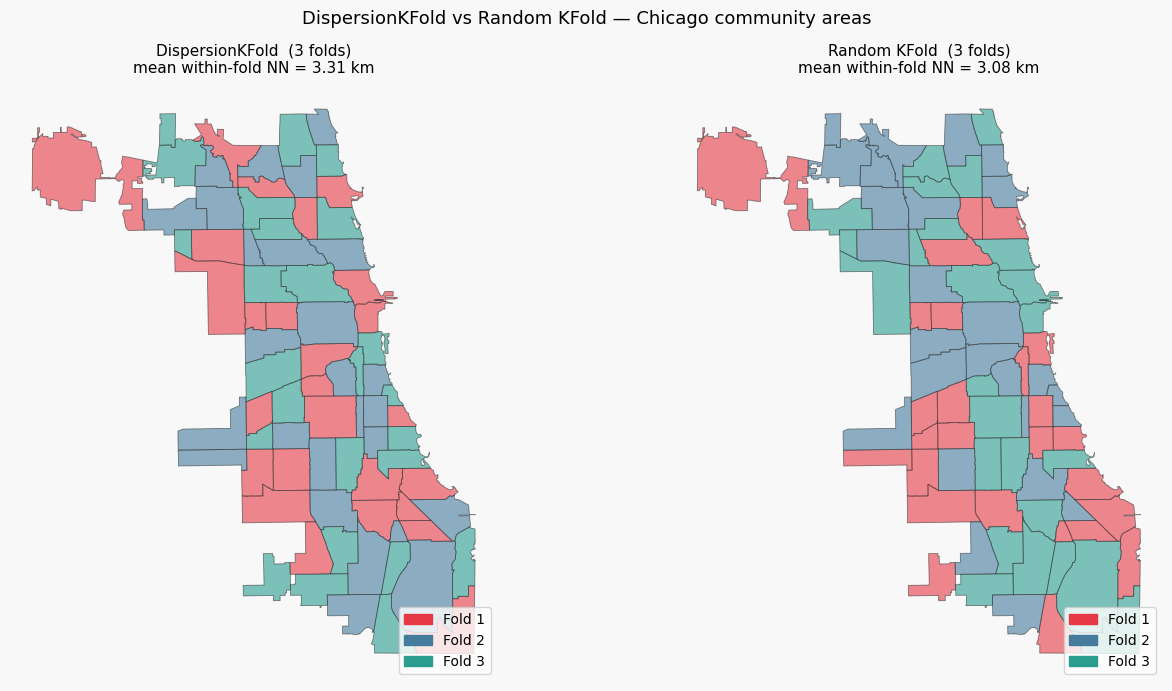

In [5]:
COLORS = ["#e63946", "#457b9d", "#2a9d8f"]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor("#f8f8f8")

for ax, labels, title in [
    (axes[0], disp_labels,
     f"DispersionKFold  (3 folds)\nmean within-fold NN = {d_disp/1000:.2f} km"),
    (axes[1], rand_labels,
     f"Random KFold  (3 folds)\nmean within-fold NN = {d_rand/1000:.2f} km"),
]:
    chicago_plot = chicago.copy()
    chicago_plot["fold"] = labels
    for fi, color in enumerate(COLORS):
        chicago_plot[chicago_plot.fold == fi].plot(
            ax=ax, color=color, alpha=0.6, edgecolor="#333", linewidth=0.6
        )
    patches = [mpatches.Patch(color=COLORS[i], label=f"Fold {i+1}")
               for i in range(N_SPLITS)]
    ax.legend(handles=patches, fontsize=10, loc="lower right")
    ax.set_title(title, fontsize=11)
    ax.set_aspect("equal"); ax.axis("off")

fig.suptitle("DispersionKFold vs Random KFold — Chicago community areas", fontsize=13)
fig.tight_layout()
plt.show()

## Cross-validation example

`split(X)` follows the sklearn cross-validator protocol and works
directly with `cross_val_score`.

In [6]:
y      = chicago["VlntCrRt"].fillna(0).values
X_feat = chicago[["PerCInc14", "Pov14", "Unemp14"]].fillna(0).values

disp_rmse, rand_rmse = [], []
for train, test in dkf.split(chicago):
    lr = LinearRegression().fit(X_feat[train], y[train])
    disp_rmse.append(root_mean_squared_error(y[test], lr.predict(X_feat[test])))
for train, test in rkf.split(coords):
    lr = LinearRegression().fit(X_feat[train], y[train])
    rand_rmse.append(root_mean_squared_error(y[test], lr.predict(X_feat[test])))

print(f"DispersionKFold  RMSE per fold: {[f'{r:.2f}' for r in disp_rmse]}  mean={np.mean(disp_rmse):.2f}")
print(f"Random KFold     RMSE per fold: {[f'{r:.2f}' for r in rand_rmse]}  mean={np.mean(rand_rmse):.2f}")

DispersionKFold  RMSE per fold: ['0.02', '0.03', '0.02']  mean=0.02
Random KFold     RMSE per fold: ['0.03', '0.02', '0.02']  mean=0.02


## Large example — King County house sales (21 k points)

With a large point dataset the spatial structure of the folds becomes
even clearer.  We use 5 folds and compare `DispersionKFold` against
random k-fold on three metrics:

1. **Fold map** — each point coloured by fold assignment
2. **Within-fold nearest-neighbour distance** — higher means each fold
   covers the whole county more uniformly
3. **Fold RMSE** — predicting log(price) from structural features;
   lower fold-to-fold variance means more reliable CV estimates

In [7]:
import geodatasets, numpy as np, geopandas as gpd

gdf_full = gpd.read_file(geodatasets.get_path("geoda.home_sales")).to_crs("EPSG:32610")
gdf_full["log_price"] = np.log(gdf_full["price"])
gdf_full["decile"] = (
    gdf_full["log_price"].rank(pct=True).multiply(10).clip(upper=9.99).astype(int)
)
idx = (
    gdf_full.groupby("decile")
    .apply(lambda g: g.sample(min(60, len(g)), random_state=42), include_groups=False)
    .index.get_level_values(1)
)
gdf = gdf_full.loc[idx].reset_index(drop=True)
print(f"n = {len(gdf)} sales  |  price ${gdf.price.min():,.0f} - ${gdf.price.max():,.0f}")

n = 600 sales  |  price $84,000 - $3,168,750


In [8]:
N_SPLITS5 = 5
y5      = np.log(gdf["price"].values)
X_feat5 = gdf[["sqft_liv", "bedrooms", "bathrooms", "grade"]].fillna(0).values
coords5 = np.column_stack([gdf.geometry.x, gdf.geometry.y])

dkf5 = DispersionKFold(n_splits=N_SPLITS5, random_state=0)
rkf5 = KFold(n_splits=N_SPLITS5, shuffle=True, random_state=0)

disp_labels5 = np.full(len(gdf), -1, dtype=int)
disp_splits5 = list(dkf5.split(gdf))
for fi, (_, test) in enumerate(disp_splits5):
    disp_labels5[test] = fi

rand_splits5 = list(rkf5.split(X_feat5, y5))
rand_labels5 = np.full(len(gdf), -1, dtype=int)
for fi, (_, test) in enumerate(rand_splits5):
    rand_labels5[test] = fi

# Within-fold NN distance
def fold_nn(splits, coords):
    means = []
    for _, test in splits:
        c = coords[test]
        from scipy.spatial.distance import cdist
        D = cdist(c, c); np.fill_diagonal(D, np.inf)
        means.append(D.min(axis=1).mean())
    return means

spatial_nn5 = fold_nn(disp_splits5, coords5)
random_nn5  = fold_nn(rand_splits5,  coords5)

# RMSE
spatial_rmse5, random_rmse5 = [], []
for train, test in disp_splits5:
    lr = LinearRegression().fit(X_feat5[train], y5[train])
    spatial_rmse5.append(root_mean_squared_error(y5[test], lr.predict(X_feat5[test])))
for train, test in rand_splits5:
    lr = LinearRegression().fit(X_feat5[train], y5[train])
    random_rmse5.append(root_mean_squared_error(y5[test], lr.predict(X_feat5[test])))

print(f"DispersionKFold mean within-fold NN: {np.mean(spatial_nn5)/1000:.2f} km")
print(f"Random KFold    mean within-fold NN: {np.mean(random_nn5)/1000:.2f} km")

DispersionKFold mean within-fold NN: 2.27 km
Random KFold    mean within-fold NN: 1.86 km


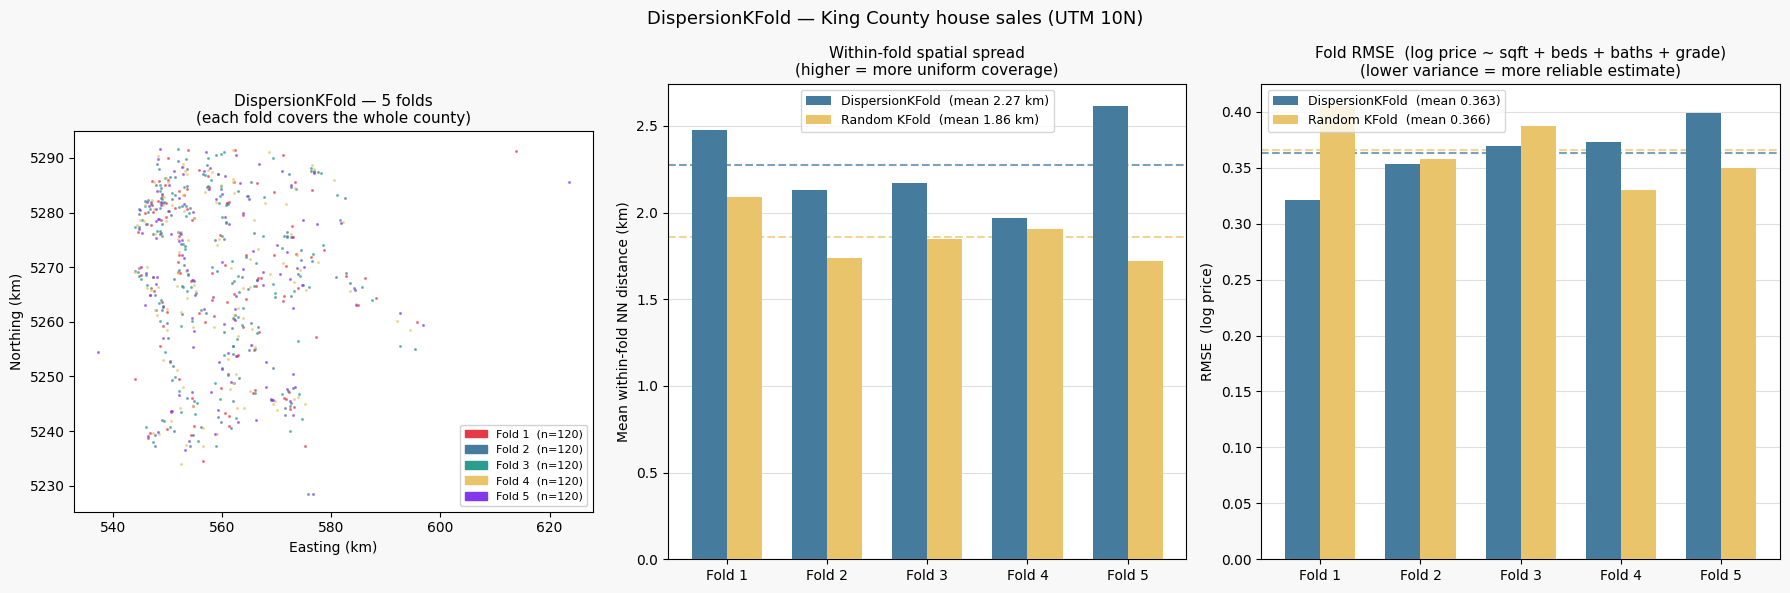

In [9]:
COLORS5 = ["#e63946", "#457b9d", "#2a9d8f", "#e9c46a", "#8338ec"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor("#f8f8f8")

# Panel 1 — fold map
ax = axes[0]
for fi in range(N_SPLITS5):
    mask = disp_labels5 == fi
    ax.scatter(gdf.geometry.x[mask]/1000, gdf.geometry.y[mask]/1000,
               c=COLORS5[fi], s=1.5, alpha=0.55)
import matplotlib.patches as mpatches5
patches5 = [mpatches.Patch(color=COLORS5[i],
            label=f"Fold {i+1}  (n={np.sum(disp_labels5==i):,})")
            for i in range(N_SPLITS5)]
ax.legend(handles=patches5, fontsize=8, loc="lower right", framealpha=0.9)
ax.set_xlabel("Easting (km)"); ax.set_ylabel("Northing (km)")
ax.set_title("DispersionKFold — 5 folds\n(each fold covers the whole county)", fontsize=11)
ax.set_aspect("equal")

# Panel 2 — within-fold NN distance
x_pos = np.arange(N_SPLITS5); w = 0.35
ax2 = axes[1]
ax2.bar(x_pos - w/2, [d/1000 for d in spatial_nn5], w, color="#457b9d",
        label=f"DispersionKFold  (mean {np.mean(spatial_nn5)/1000:.2f} km)", zorder=3)
ax2.bar(x_pos + w/2, [d/1000 for d in random_nn5],  w, color="#e9c46a",
        label=f"Random KFold  (mean {np.mean(random_nn5)/1000:.2f} km)", zorder=3)
ax2.axhline(np.mean(spatial_nn5)/1000, color="#457b9d", lw=1.5, ls="--", alpha=0.7)
ax2.axhline(np.mean(random_nn5)/1000,  color="#e9c46a", lw=1.5, ls="--", alpha=0.7)
ax2.set_xticks(x_pos); ax2.set_xticklabels([f"Fold {i+1}" for i in range(N_SPLITS5)])
ax2.set_ylabel("Mean within-fold NN distance (km)")
ax2.set_title("Within-fold spatial spread\n(higher = more uniform coverage)", fontsize=11)
ax2.legend(fontsize=9); ax2.yaxis.grid(True, alpha=0.4); ax2.set_axisbelow(True)

# Panel 3 — RMSE
ax3 = axes[2]
ax3.bar(x_pos - w/2, spatial_rmse5, w, color="#457b9d",
        label=f"DispersionKFold  (mean {np.mean(spatial_rmse5):.3f})", zorder=3)
ax3.bar(x_pos + w/2, random_rmse5,  w, color="#e9c46a",
        label=f"Random KFold  (mean {np.mean(random_rmse5):.3f})", zorder=3)
ax3.axhline(np.mean(spatial_rmse5), color="#457b9d", lw=1.5, ls="--", alpha=0.7)
ax3.axhline(np.mean(random_rmse5),  color="#e9c46a", lw=1.5, ls="--", alpha=0.7)
ax3.set_xticks(x_pos); ax3.set_xticklabels([f"Fold {i+1}" for i in range(N_SPLITS5)])
ax3.set_ylabel("RMSE  (log price)")
ax3.set_title("Fold RMSE  (log price ~ sqft + beds + baths + grade)\n"
              "(lower variance = more reliable estimate)", fontsize=11)
ax3.legend(fontsize=9); ax3.yaxis.grid(True, alpha=0.4); ax3.set_axisbelow(True)

fig.suptitle("DispersionKFold — King County house sales (UTM 10N)", fontsize=13)
fig.tight_layout()
plt.show()